## 00 Read Data

### Setup und Hilfsfunktionen

In [ ]:
%matplotlib inline

import numpy as np 
import pandas as pd

import numba
import torch

from pathlib import Path

from matplotlib import pyplot as plt

from scipy import sparse

from threadpoolctl import ThreadpoolController, threadpool_limits

%load_ext cython
import random
import numpy as np
import torch

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [4]:
CURRENT_WORKING_DIRECTORY = Path.cwd()
CURRENT_WORKING_DIRECTORY

PosixPath('/Users/anasshbat/Desktop/Uni-mac/Winter26/Projeckt_GNN/gnn_uni')

### Beispielgraph und Feature-Check

In [5]:
BASEPATH = CURRENT_WORKING_DIRECTORY / "data/00_grids"
file_path = BASEPATH / "00000_grid_101x101x101__grains_16.npz"

g2g = GrainsToGraph(filepath=file_path)

g2g.filepath
g2g.edge_information(as_frame=True).info()
g2g.node_information(as_frame=True).info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   center_node    110 non-null    int32  
 1   neighbor_node  110 non-null    int32  
 2   contact_area   110 non-null    float32
 3   distance       110 non-null    float32
dtypes: float32(2), int32(2)
memory usage: 1.8 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   center-coord-0  16 non-null     float32
 1   center-coord-1  16 non-null     float32
 2   center-coord-2  16 non-null     float32
 3   degree          16 non-null     int32  
 4   volume          16 non-null     float32
dtypes: float32(4), int32(1)
memory usage: 452.0 bytes


### Widerstandsdatensatz vorbereiten

In [6]:
import pandas as pd
import numpy as np

# CSV-Daten einlesen
df = pd.read_csv(csv_path, comment='#', header=0)

# Erste Zeile enthält die rho_ratio-Werte
rho_ratios = df.columns[1:].astype(float)

# Leeren DataFrame für alle Daten vorbereiten
all_data = []

# Für jede Grain-Zeile
for idx, row in df.iterrows():
    grain = row['Grains']
    values = row[1:].values
    
    # Für jedes rho_ratio einen Eintrag erstellen
    for rho, val in zip(rho_ratios, values):
        all_data.append({
            'Grains': grain,
            'rho_ratio': rho,
            'R_tot_Ohm': val
        })

# Zu DataFrame konvertieren
df_R = pd.DataFrame(all_data)

df_R.info

# Spalte 'Grains' zu 'grains' umbenennen
df_R = df_R.rename(columns={"Grains": "grains", "rho_ratio": "leitfaehigkeit", "R_tot_Ohm": "widerstand"})

# Optional: prüfen
print(df_R.head())


NameError: name 'csv_path' is not defined

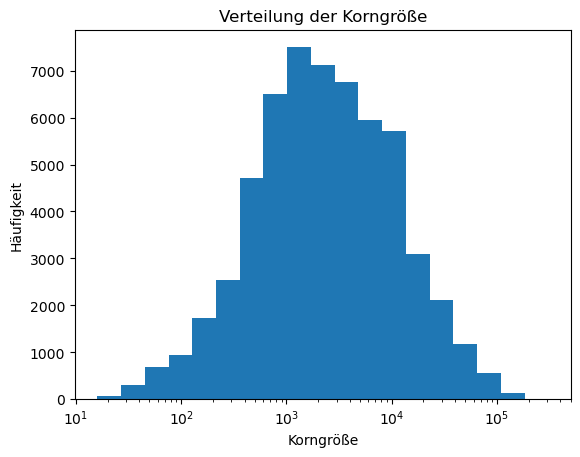

In [ ]:
def plot_grain_distribution(df: pd.DataFrame) -> None:
    """Plot the grain-size distribution on a logarithmic x-axis."""
    grains = df.loc[df["grains"] > 0, "grains"]
    bins = np.logspace(np.log10(grains.min()), np.log10(grains.max()), 20)

    fig, ax = plt.subplots()
    ax.hist(grains, bins=bins)
    ax.set_xscale("log")
    ax.set_xlabel("Korngroesse")
    ax.set_ylabel("Haeufigkeit")
    ax.set_title("Verteilung der Korngroesse")
    ax.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_mean_resistance(
    df: pd.DataFrame,
    x_column: str,
    x_label: str,
    title: str,
    marker: str = "o",
) -> None:
    """Plot mean resistance against a selected feature on log-log axes."""
    grouped = df.groupby(x_column)["widerstand"].mean()

    fig, ax = plt.subplots()
    ax.plot(grouped.index.to_numpy(), grouped.to_numpy(), marker=marker)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Widerstand")
    ax.set_title(title)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_eda_plots(df: pd.DataFrame) -> None:
    """Run the standard EDA plots used in this notebook."""
    plot_grain_distribution(df)
    plot_mean_resistance(
        df=df,
        x_column="grains",
        x_label="Grain Size",
        title="Mittlerer Widerstand vs. Grain Size",
    )
    plot_mean_resistance(
        df=df,
        x_column="leitfaehigkeit",
        x_label="Leitfaehigkeit",
        title="Mittlerer Widerstand vs. Leitfaehigkeit",
    )


run_eda_plots(df_resistance)

## Mapping: Grid zu Graph-Dataset

In [ ]:
class CustomGridDataset(Dataset):
    """Create PyG data objects from grid files and resistance measurements."""

    def __init__(
        self,
        grids_folder: Path,
        resistance_df: pd.DataFrame,
        node_scaler=None,
        edge_scaler=None,
        transform=None,
        grid_files: list[Path] | None = None,
        measurements_per_grain: int = 62,
    ) -> None:
        super().__init__()
        self.grid_files = (
            sorted(grid_files)
            if grid_files is not None
            else sorted(grids_folder.glob("*.npz"))
        )
        self.resistance_df = resistance_df
        self.node_scaler = node_scaler
        self.edge_scaler = edge_scaler
        self.transform = transform
        self.measurements_per_grain = measurements_per_grain

    @staticmethod
    def _extract_grain_count(grid_path: Path) -> int:
        match = re.search(r"grains_(\d+)", grid_path.name)
        if match is None:
            raise ValueError(f"Could not extract grain count from: {grid_path.name}")
        return int(match.group(1))

    def __len__(self) -> int:
        return len(self.grid_files)

    def __getitem__(self, index: int) -> Data:
        grid_path = self.grid_files[index]
        grain_count = self._extract_grain_count(grid_path)
        matching_rows = self.resistance_df[self.resistance_df["grains"] == grain_count]

        if len(matching_rows) < self.measurements_per_grain:
            raise ValueError(
                f"Grain {grain_count}: expected at least "
                f"{self.measurements_per_grain} measurements, got {len(matching_rows)}"
            )

        matching_rows = matching_rows.iloc[: self.measurements_per_grain]
        conductivity_values = matching_rows["leitfaehigkeit"].to_numpy(dtype=float)
        resistance_values = matching_rows["widerstand"].to_numpy(dtype=float)

        graph = GrainsToGraph(filepath=grid_path)

        node_features = graph.node_information()
        if self.node_scaler is not None:
            node_features = self.node_scaler.transform(node_features)

        edge_features = graph.edge_information()
        if self.edge_scaler is not None:
            edge_features = self.edge_scaler.transform(edge_features)

        data = Data(
            x=torch.from_numpy(node_features).float(),
            edge_index=torch.from_numpy(graph.neighbor_pairs).T.long(),
            edge_attr=torch.from_numpy(edge_features).float(),
            y=torch.tensor(resistance_values, dtype=torch.float32),
        )
        data.adj = torch.from_numpy(graph.adjacency_matrix().toarray()).float()
        data.global_attr = torch.tensor(
            conductivity_values, dtype=torch.float32
        ).unsqueeze(1)

        if self.transform is not None:
            data = self.transform(data)

        return data

In [ ]:
dataset = CustomGridDataset(
    grids_folder=GRIDS_DIRECTORY,
    resistance_df=df_resistance,
)

dataset_size = len(dataset)
dataset_size

6

In [ ]:
def summarize_sample(data: Data) -> dict[str, tuple[int, ...]]:
    """Return key tensor shapes for a single graph sample."""
    return {
        "x": tuple(data.x.shape),
        "edge_index": tuple(data.edge_index.shape),
        "edge_attr": tuple(data.edge_attr.shape),
        "global_attr": tuple(data.global_attr.shape),
        "adj": tuple(data.adj.shape),
        "y": tuple(data.y.shape),
    }


sample_data = dataset[1]
summarize_sample(sample_data)

Data(x=[33, 5], edge_index=[2, 286], edge_attr=[286, 2], y=[62], adj=[33, 33], global_attr=[62, 1])
x: torch.Size([33, 5])
edge_index: torch.Size([2, 286])
edge_attr: torch.Size([286, 2])
global_attr: torch.Size([62, 1])
adj: torch.Size([33, 33])
y: torch.Size([62])


torch.Size([62])